In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings


# IMPORTACIONES ACTUALIZADAS
from src.modeling            import get_base_models, tune_hyperparameters, cross_validate_models, train_and_save
from src.evaluation          import (
    plot_cv_comparison, save_tuning_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
SAMPLE_SIZE  = 100_000
RAW_PATH     = '../data/raw/global_youtube_creator_data_large.csv'
FIGURES_DIR  = '../reports/figures'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


In [8]:
import os, pickle
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(''))
while PROJECT_ROOT.name != 'Proyecto_Final_ML':
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
print("Working dir:", PROJECT_ROOT)

# Cargar artefactos de Fase 3
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase3_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

X_train_proc       = artifacts['X_train_proc']
X_test_proc        = artifacts['X_test_proc']
y_train            = artifacts['y_train']
y_test             = artifacts['y_test']
df                 = artifacts['df_clean']
feature_names_proc = artifacts['feature_names_proc']

print("Artefactos de Fase 3 cargados")

Working dir: c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML
Artefactos de Fase 3 cargados


---
# FASE 4 | MODELADO (Modeling)
---

## 4.1 Descripción de modelos

### Regresión Logística
Modelo lineal baseline. Sirve como referencia de complejidad mínima. Requiere escalado (ya aplicado por StandardScaler).

### Random Forest
Ensamble de árboles con *bagging* sobre subconjuntos aleatorios de datos y features. Robusto al ruido, maneja relaciones no lineales y provee importancia de características.

### Gradient Boosting
Ensamble secuencial donde cada árbol corrige los errores del anterior. `learning_rate` bajo con muchos estimadores equilibra bias-varianza.

### Hist Gradient Boosting
Implementación basada en **histogramas** (similar a LightGBM), incluida en scikit-learn desde v0.24. Agrupa los valores de cada feature en bins antes de buscar divisiones, lo que la hace **5-20× más rápida** que `GradientBoostingClassifier` y generalmente obtiene mejor ROC-AUC gracias a:
- Bins adaptativos que mejoran la granularidad de las divisiones.
- Regularización L2 nativa que reduce el sobreajuste.
- Manejo nativo de valores NaN (aunque no aplica aquí).

## 4.2 Validación cruzada estratificada (5-fold)

**StratifiedKFold** garantiza la misma proporción de clases en cada fold. Se usa `n_iter=30` en la búsqueda aleatoria para un balance entre exhaustividad y tiempo de cómputo.

In [9]:
base_models = get_base_models(random_state=RANDOM_STATE)

print('Iniciando busqueda de hiperparametros...')
print('n_iter=40  — HGBC es 10x mas rapido que GBM clasico.\n')

best_models = tune_hyperparameters(
    base_models, X_train_proc, y_train.values,
    n_iter=10, cv_folds=3, random_state=RANDOM_STATE
)

save_tuning_report(best_models,
                   save_path=str(PROJECT_ROOT / 'reports' / 'best_hyperparameters.json'))

Iniciando busqueda de hiperparametros...
n_iter=40  — HGBC es 10x mas rapido que GBM clasico.


[TUNING] Iniciando busqueda para: Regresion Logistica
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Mejor ROC-AUC (CV): 0.6649
    Mejores params: {'C': np.float64(14.528246637516036), 'class_weight': 'balanced'}
    Tiempo de busqueda: 18.2s

[TUNING] Iniciando busqueda para: Random Forest
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Mejor ROC-AUC (CV): 0.6786
    Mejores params: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 13, 'n_estimators': 154}
    Tiempo de busqueda: 252.1s

[TUNING] Iniciando busqueda para: Gradient Boosting
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Mejor ROC-AUC (CV): 0.6790
    Mejores params: {'learning_rate': np.float64(0.012151617026673379), 'max_depth': 6, 'min_samples_leaf': 29, 'n_estimators': 159, 'subsample': np.float64(0.8689864653536618)}
    Tiempo de busq

In [10]:
print('\nIniciando validación cruzada estratificada (5-fold) sobre los modelos OPTIMIZADOS...')

cv_results = cross_validate_models(
    best_models, X_train_proc, y_train.values,
    cv_folds=5, random_state=RANDOM_STATE
)


Iniciando validación cruzada estratificada (5-fold) sobre los modelos OPTIMIZADOS...

[CV] Validando modelo optimizado: Regresion Logistica (5 folds)...
    F1       : 0.6191 ± 0.0030
    ROC-AUC  : 0.6650 ± 0.0033

[CV] Validando modelo optimizado: Random Forest (5 folds)...
    F1       : 0.6612 ± 0.0035
    ROC-AUC  : 0.6788 ± 0.0050

[CV] Validando modelo optimizado: Gradient Boosting (5 folds)...
    F1       : 0.6559 ± 0.0020
    ROC-AUC  : 0.6792 ± 0.0045

[CV] Validando modelo optimizado: Hist Gradient Boosting (5 folds)...
    F1       : 0.6560 ± 0.0034
    ROC-AUC  : 0.6788 ± 0.0045


In [11]:
print('\nResumen de Validacion Cruzada:')
cols_show = ['ROC-AUC (val)', 'ROC-AUC std', 'F1 (val)', 'F1 std',
             'Accuracy (val)', 'Accuracy std', 'Precision (val)', 'Recall (val)',
             'Accuracy (train)', 'Tiempo (s)']
display(cv_results[cols_show].round(4))


Resumen de Validacion Cruzada:


,ROC-AUC (val),ROC-AUC std,F1 (val),F1 std,Accuracy (val),Accuracy std,Precision (val),Recall (val),Accuracy (train),Tiempo (s)
Regresion Logistica,0.6650,0.0033,0.6191,0.0030,0.6147,0.0031,0.6121,0.6264,0.6148,0.9
Random Forest,0.6788,0.0050,0.6612,0.0035,0.6238,0.0046,0.6015,0.7343,0.6512,37.4
Gradient Boosting,0.6792,0.0045,0.6559,0.0020,0.6238,0.0044,0.6044,0.7170,0.6317,283.5
Hist Gradient Boosting,0.6788,0.0045,0.6560,0.0034,0.6235,0.0045,0.6039,0.7180,0.6316,10.7


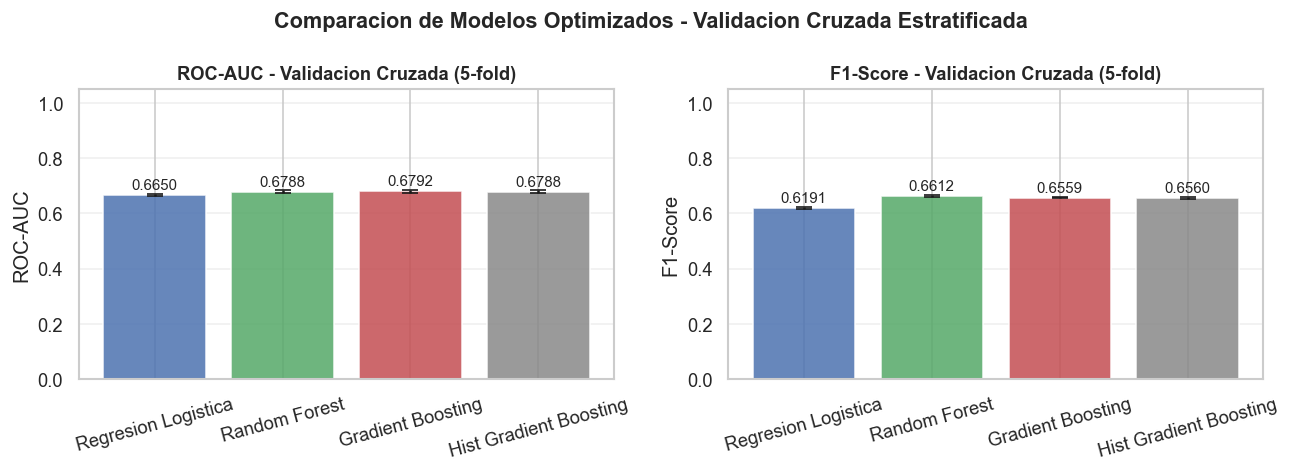

[INFO] Figura guardada: ../reports/figures/cv_comparison.png


In [12]:
plot_cv_comparison(cv_results, save_path=f'{FIGURES_DIR}/cv_comparison.png')

## 4.3 Analisis de sobreajuste (overfitting)

La diferencia entre `Accuracy (train)` y `Accuracy (val)` en la validacion cruzada indica el grado de sobreajuste.

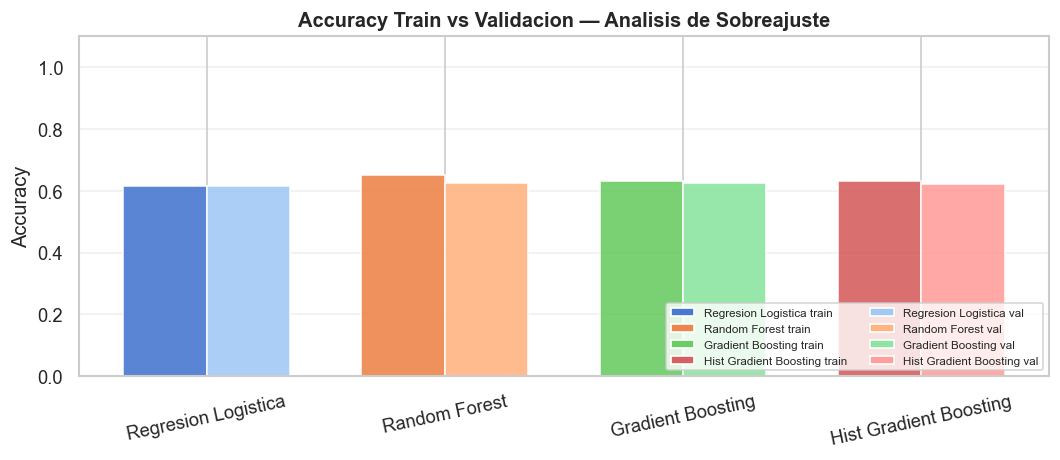


Diferencia Train - Val (indica sobreajuste):
  Regresion Logistica           : +0.0001
  Random Forest                 : +0.0274
  Gradient Boosting             : +0.0079
  Hist Gradient Boosting        : +0.0081


In [13]:
fig, ax = plt.subplots(figsize=(9, 4))

n_models     = len(cv_results)
x            = np.arange(n_models)
w            = 0.35
palette_dark  = sns.color_palette('muted',  n_models)
palette_light = sns.color_palette('pastel', n_models)

for i, (name, row) in enumerate(cv_results.iterrows()):
    ax.bar(x[i] - w/2, row['Accuracy (train)'], w,
           color=palette_dark[i],  alpha=0.9,
           label=f'{name} (train)')
    ax.bar(x[i] + w/2, row['Accuracy (val)'],   w,
           color=palette_light[i], alpha=0.9,
           label=f'{name} (val)')

ax.set_xticks(x)
ax.set_xticklabels(cv_results.index, rotation=12)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.set_title('Accuracy Train vs Validacion — Analisis de Sobreajuste', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements  = [Patch(facecolor=palette_dark[i],  label=f'{n} train')
                    for i, n in enumerate(cv_results.index)]
legend_elements += [Patch(facecolor=palette_light[i], label=f'{n} val')
                    for i, n in enumerate(cv_results.index)]
ax.legend(handles=legend_elements, loc='lower right', fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/overfitting_analysis.png', bbox_inches='tight')
plt.show()

print('\nDiferencia Train - Val (indica sobreajuste):')
for name, row in cv_results.iterrows():
    diff = row['Accuracy (train)'] - row['Accuracy (val)']
    print(f'  {name:30}: {diff:+.4f}')

## 4.4 Entrenamiento final sobre todo el conjunto de entrenamiento

In [14]:
trained_models = {}
for name, model in best_models.items():
    trained_models[name] = train_and_save(
        model, name, X_train_proc, y_train.values,
        models_dir=str(PROJECT_ROOT / 'models')
    )

[INFO] Entrenando modelo final Regresion Logistica...
[INFO] Regresion Logistica entrenado en 1.5s -> guardado en c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\models\regresion_logistica.joblib
[INFO] Entrenando modelo final Random Forest...
[INFO] Random Forest entrenado en 9.8s -> guardado en c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\models\random_forest.joblib
[INFO] Entrenando modelo final Gradient Boosting...
[INFO] Gradient Boosting entrenado en 141.1s -> guardado en c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\models\gradient_boosting.joblib
[INFO] Entrenando modelo final Hist Gradient Boosting...
[INFO] Hist Gradient Boosting entrenado en 2.8s -> guardado en c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\models\hist_gradient_boosting.joblib


In [15]:
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase4_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'trained_models': trained_models,
        'best_models':    best_models,
        'cv_results':     cv_results 
    }, f)

print("Guardado en:", PROJECT_ROOT / 'data' / 'processed' / 'fase4_artifacts.pkl')

Guardado en: c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\data\processed\fase4_artifacts.pkl
